<a href="https://colab.research.google.com/github/emraankazmi5-coder/deeplearning/blob/main/Practicum%20project%20on%20youtube.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind, f_oneway
import statsmodels.api as sm
import statsmodels.formula.api as smf

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nelgiriyewithana/global-youtube-statistics-2023")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'global-youtube-statistics-2023' dataset.
Path to dataset files: /kaggle/input/global-youtube-statistics-2023


In [ ]:
import pandas as pd

df = pd.read_csv("Global YouTube Statistics.csv", encoding="latin1")
df.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,video_views_rank,country_rank,channel_type_rank,video_views_for_the_last_30_days,lowest_monthly_earnings,highest_monthly_earnings,lowest_yearly_earnings,highest_yearly_earnings,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,1.0,1.0,1.0,2.258000e+09,564600.0,9000000.00,6800000.00,1.084000e+08,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,4055159.0,7670.0,7423.0,1.200000e+01,0.0,0.05,0.04,5.800000e-01,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,48.0,1.0,1.0,1.348000e+09,337000.0,5400000.00,4000000.00,6.470000e+07,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,2.0,2.0,1.0,1.975000e+09,493800.0,7900000.00,5900000.00,9.480000e+07,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,3.0,2.0,2.0,1.824000e+09,455900.0,7300000.00,5500000.00,8.750000e+07,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [ ]:
df = pd.read_csv("Global YouTube Statistics.csv", encoding_errors="ignore")


In [ ]:
# ============================================
# 3. CHECK BASIC SHAPE AND COLUMNS
# ============================================
print("Rows and Columns:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False))


Rows and Columns: (995, 28)

Columns:
['rank', 'Youtuber', 'subscribers', 'video views', 'category', 'Title', 'uploads', 'Country', 'Abbreviation', 'channel_type', 'video_views_rank', 'country_rank', 'channel_type_rank', 'video_views_for_the_last_30_days', 'lowest_monthly_earnings', 'highest_monthly_earnings', 'lowest_yearly_earnings', 'highest_yearly_earnings', 'subscribers_for_last_30_days', 'created_year', 'created_month', 'created_date', 'Gross tertiary education enrollment (%)', 'Population', 'Unemployment rate', 'Urban_population', 'Latitude', 'Longitude']

Missing Values:
subscribers_for_last_30_days               337
Latitude                                   123
Urban_population                           123
Longitude                                  123
Population                                 123
Gross tertiary education enrollment (%)    123
Unemployment rate                          123
Abbreviation                               122
Country                               

In [ ]:
# Data Cleaning
# ============================================
# 4. CLEAN COLUMN NAMES
# ============================================
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(" ", "_")
              .str.replace(".", "", regex=False)
)

print(df.columns.tolist())


['rank', 'youtuber', 'subscribers', 'video_views', 'category', 'title', 'uploads', 'country', 'abbreviation', 'channel_type', 'video_views_rank', 'country_rank', 'channel_type_rank', 'video_views_for_the_last_30_days', 'lowest_monthly_earnings', 'highest_monthly_earnings', 'lowest_yearly_earnings', 'highest_yearly_earnings', 'subscribers_for_last_30_days', 'created_year', 'created_month', 'created_date', 'gross_tertiary_education_enrollment_(%)', 'population', 'unemployment_rate', 'urban_population', 'latitude', 'longitude']


In [ ]:
# ============================================
# 5. RENAME A FEW IMPORTANT COLUMNS
# ============================================
df = df.rename(columns={
    "video_views": "video_views",
    "lowest_monthly_earnings": "lowest_monthly_earnings",
    "highest_monthly_earnings": "highest_monthly_earnings",
    "lowest_yearly_earnings": "lowest_yearly_earnings",
    "highest_yearly_earnings": "highest_yearly_earnings",
    "gross_tertiary_education_enrollment": "education_enrollment",
    "urban_population": "urban_population"
})

print(df.columns.tolist())


['rank', 'youtuber', 'subscribers', 'video_views', 'category', 'title', 'uploads', 'country', 'abbreviation', 'channel_type', 'video_views_rank', 'country_rank', 'channel_type_rank', 'video_views_for_the_last_30_days', 'lowest_monthly_earnings', 'highest_monthly_earnings', 'lowest_yearly_earnings', 'highest_yearly_earnings', 'subscribers_for_last_30_days', 'created_year', 'created_month', 'created_date', 'gross_tertiary_education_enrollment_(%)', 'population', 'unemployment_rate', 'urban_population', 'latitude', 'longitude']


In [ ]:
# ============================================
# 6. CONVERT IMPORTANT COLUMNS TO NUMERIC
# ============================================
numeric_cols = [
    "subscribers",
    "video_views",
    "uploads",
    "video_views_for_the_last_30_days",
    "lowest_monthly_earnings",
    "highest_monthly_earnings",
    "lowest_yearly_earnings",
    "highest_yearly_earnings",
    "subscribers_for_last_30_days",
    "created_year",
    "population",
    "unemployment_rate",
    "urban_population",
    "gross_tertiary_education_enrollment",
    "latitude",
    "longitude"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   rank                                     995 non-null    int64  
 1   youtuber                                 989 non-null    object 
 2   subscribers                              995 non-null    int64  
 3   video_views                              995 non-null    float64
 4   category                                 949 non-null    object 
 5   title                                    990 non-null    object 
 6   uploads                                  995 non-null    int64  
 7   country                                  873 non-null    object 
 8   abbreviation                             873 non-null    object 
 9   channel_type                             965 non-null    object 
 10  video_views_rank                         994 non-n

In [ ]:
# ============================================
# 7. HANDLE MISSING VALUES
# ============================================
critical_cols = [
    "category", "country", "subscribers", "video_views", "uploads"
]

df_clean = df.dropna(subset=[c for c in critical_cols if c in df.columns]).copy()

# Optional: fill non-critical text fields
for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = df_clean[col].fillna("Data Not Available")

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)


Original shape: (995, 28)
Cleaned shape: (834, 28)


In [ ]:
# ============================================
# 8. FEATURE ENGINEERING
# ============================================
# Channel age
if "created_year" in df_clean.columns:
    df_clean["channel_age"] = 2026 - df_clean["created_year"]

# Avoid divide-by-zero issues
df_clean["uploads"] = df_clean["uploads"].replace(0, np.nan)
df_clean["subscribers"] = df_clean["subscribers"].replace(0, np.nan)

# Engagement-style ratios
df_clean["views_per_subscriber"] = df_clean["video_views"] / df_clean["subscribers"]
df_clean["subscribers_per_upload"] = df_clean["subscribers"] / df_clean["uploads"]
df_clean["views_per_upload"] = df_clean["video_views"] / df_clean["uploads"]

# Performance score using normalized variables
score_cols = ["subscribers", "video_views", "highest_yearly_earnings"]
available_score_cols = [c for c in score_cols if c in df_clean.columns]

for c in available_score_cols:
    df_clean[c + "_z"] = stats.zscore(df_clean[c], nan_policy="omit")

if set(["subscribers_z", "video_views_z", "highest_yearly_earnings_z"]).issubset(df_clean.columns):
    df_clean["performance_score"] = (
        0.5 * df_clean["subscribers_z"] +
        0.3 * df_clean["video_views_z"] +
        0.2 * df_clean["highest_yearly_earnings_z"]
    )

    q1 = df_clean["performance_score"].quantile(0.25)
    q3 = df_clean["performance_score"].quantile(0.75)

    def classify_perf(x):
        if x >= q3:
            return "Top Performer"
        elif x <= q1:
            return "Bottom Performer"
        else:
            return "Middle Performer"

    df_clean["performance_category"] = df_clean["performance_score"].apply(classify_perf)

df_clean.head()


,rank,youtuber,subscribers,video_views,category,title,uploads,country,abbreviation,channel_type,video_views_rank,country_rank,channel_type_rank,video_views_for_the_last_30_days,lowest_monthly_earnings,highest_monthly_earnings,lowest_yearly_earnings,highest_yearly_earnings,subscribers_for_last_30_days,created_year,created_month,created_date,gross_tertiary_education_enrollment_(%),population,unemployment_rate,urban_population,latitude,longitude,channel_age,views_per_subscriber,subscribers_per_upload,views_per_upload,subscribers_z,video_views_z,highest_yearly_earnings_z,performance_score,performance_category
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082.0,India,IN,Music,1.0,1.0,1.0,2.258000e+09,564600.0,9000000.00,6800000.00,1.084000e+08,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880,20.0,930.612245,1.219998e+04,1.135345e+07,12.284159,14.420319,7.989143,12.066004,Top Performer
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1.0,United States,US,Games,4055159.0,7670.0,7423.0,1.200000e+01,0.0,0.05,0.04,5.800000e-01,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891,20.0,0.000000,1.700000e+08,0.000000e+00,8.134253,-0.758519,-0.570614,3.725448,Top Performer
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741.0,United States,US,Entertainment,48.0,1.0,1.0,1.348000e+09,337000.0,5400000.00,4000000.00,6.470000e+07,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891,14.0,170.896638,2.240216e+05,3.828454e+07,7.912925,1.130104,4.538392,5.203172,Top Performer
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966.0,United States,US,Education,2.0,2.0,1.0,1.975000e+09,493800.0,7900000.00,5900000.00,9.480000e+07,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891,20.0,1012.345679,1.677019e+05,1.697723e+08,7.691596,10.159593,6.915226,8.276721,Top Performer
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536.0,India,IN,Entertainment,3.0,2.0,2.0,1.824000e+09,455900.0,7300000.00,5500000.00,8.750000e+07,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880,20.0,930.817610,1.364385e+03,1.269994e+06,7.525600,9.094411,6.338784,7.758880,Top Performer


In [ ]:
# ============================================
# 9. SUMMARY STATISTICS
# ============================================
df_clean[["subscribers", "video_views", "uploads"]].describe()


,subscribers,video_views,uploads
count,8.340000e+02,8.340000e+02,817.000000
mean,2.299209e+07,1.139365e+10,11058.932681
std,1.808354e+07,1.502993e+10,37424.814499
min,1.230000e+07,0.000000e+00,1.000000
25%,1.450000e+07,4.308531e+09,323.000000
50%,1.760000e+07,7.768225e+09,975.000000
75%,2.410000e+07,1.361947e+10,3640.000000
max,2.450000e+08,2.280000e+11,301308.000000


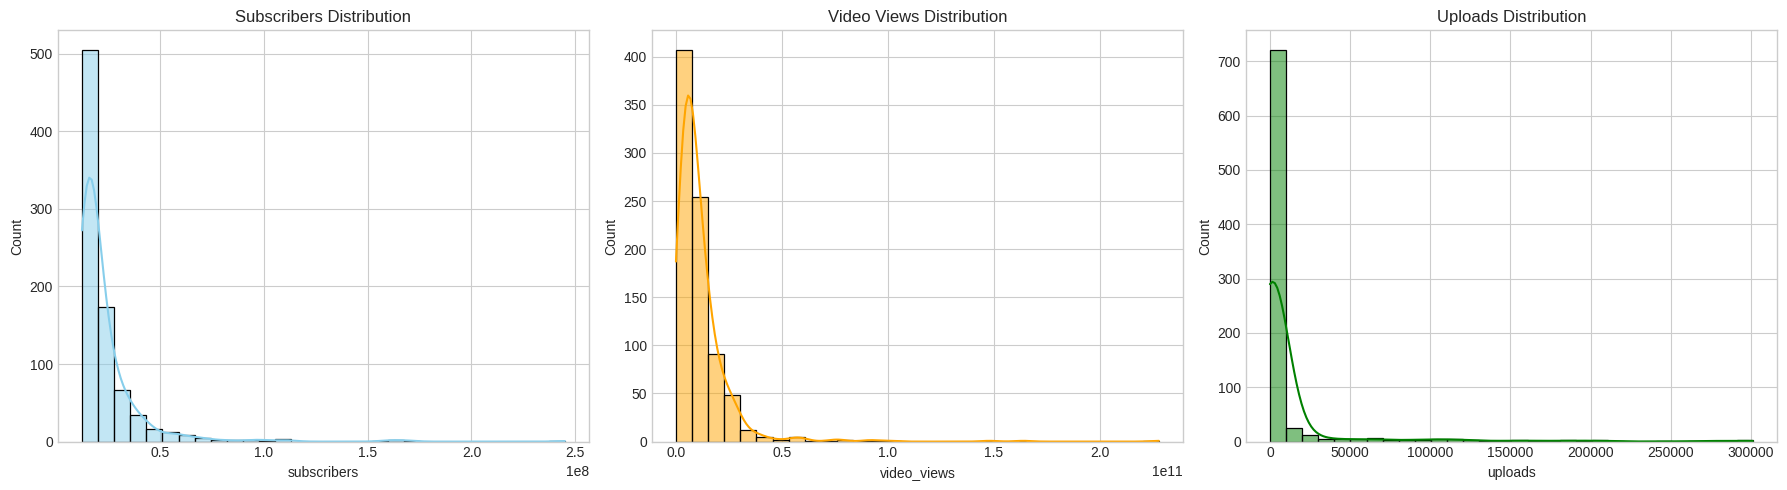

In [ ]:
# ============================================
# 10. HISTOGRAMS
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_clean["subscribers"], bins=30, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Subscribers Distribution")

sns.histplot(df_clean["video_views"], bins=30, kde=True, ax=axes[1], color="orange")
axes[1].set_title("Video Views Distribution")

sns.histplot(df_clean["uploads"].dropna(), bins=30, kde=True, ax=axes[2], color="green")
axes[2].set_title("Uploads Distribution")

plt.tight_layout()
plt.show()


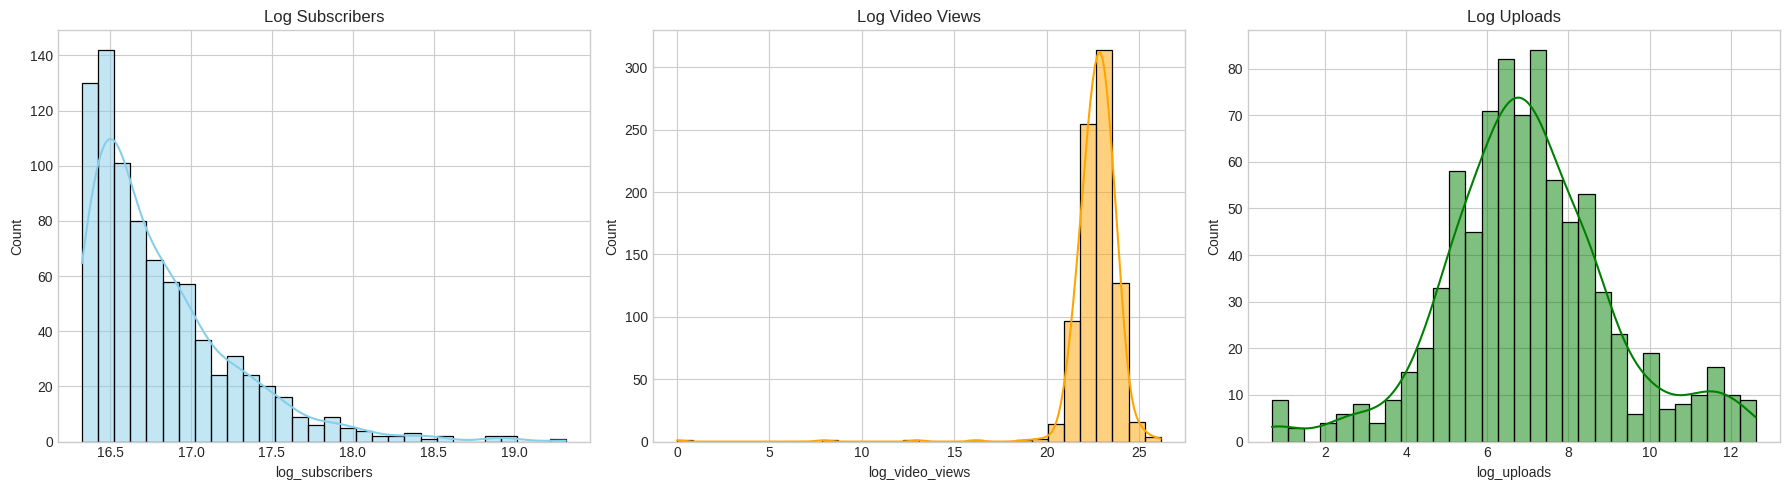

In [ ]:
# ============================================
# 11. LOG-TRANSFORMED PLOTS (BETTER FOR SKEWED DATA)
# ============================================
df_clean["log_subscribers"] = np.log1p(df_clean["subscribers"])
df_clean["log_video_views"] = np.log1p(df_clean["video_views"])
df_clean["log_uploads"] = np.log1p(df_clean["uploads"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_clean["log_subscribers"], bins=30, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Log Subscribers")

sns.histplot(df_clean["log_video_views"], bins=30, kde=True, ax=axes[1], color="orange")
axes[1].set_title("Log Video Views")

sns.histplot(df_clean["log_uploads"].dropna(), bins=30, kde=True, ax=axes[2], color="green")
axes[2].set_title("Log Uploads")

plt.tight_layout()
plt.show()


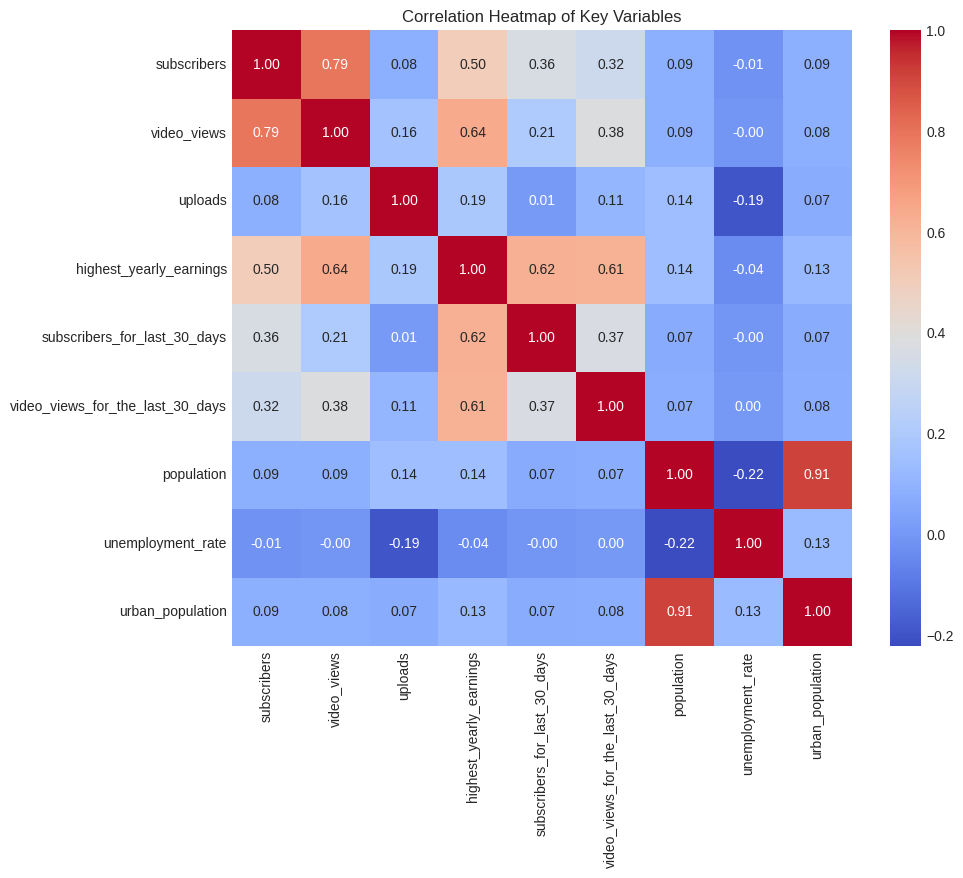

In [ ]:
# ============================================
# 12. CORRELATION MATRIX
# ============================================
corr_cols = [
    "subscribers",
    "video_views",
    "uploads",
    "highest_yearly_earnings",
    "subscribers_for_last_30_days",
    "video_views_for_the_last_30_days",
    "population",
    "unemployment_rate",
    "urban_population",
    "gross_tertiary_education_enrollment"
]

corr_cols = [c for c in corr_cols if c in df_clean.columns]

corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Key Variables")
plt.show()


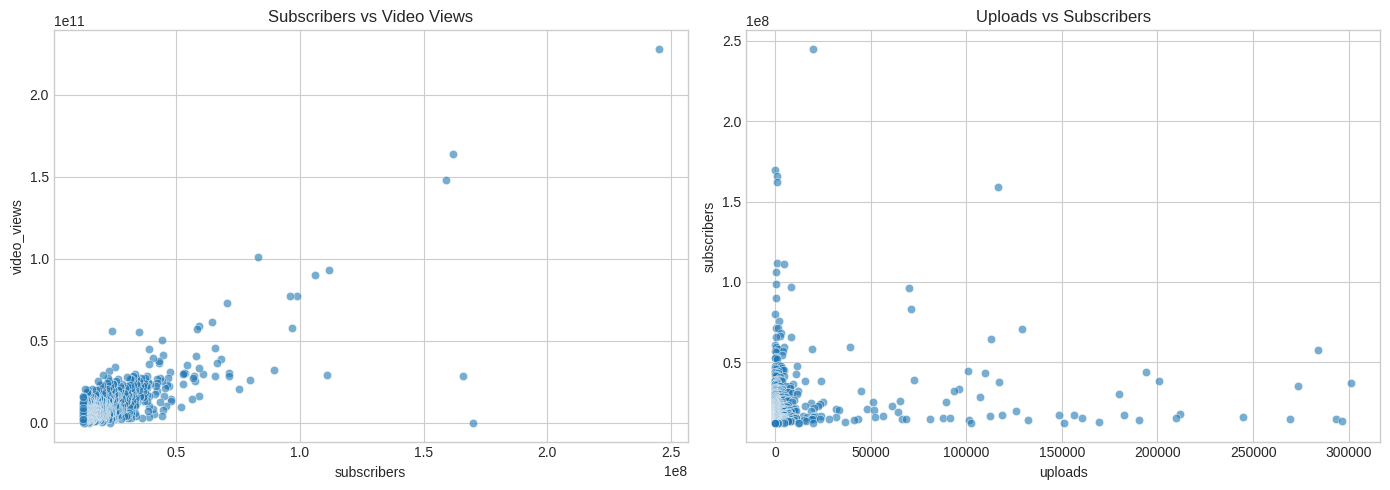

In [ ]:
# ============================================
# 13. SCATTER PLOTS
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df_clean, x="subscribers", y="video_views", alpha=0.6, ax=axes[0])
axes[0].set_title("Subscribers vs Video Views")

sns.scatterplot(data=df_clean, x="uploads", y="subscribers", alpha=0.6, ax=axes[1])
axes[1].set_title("Uploads vs Subscribers")

plt.tight_layout()
plt.show()


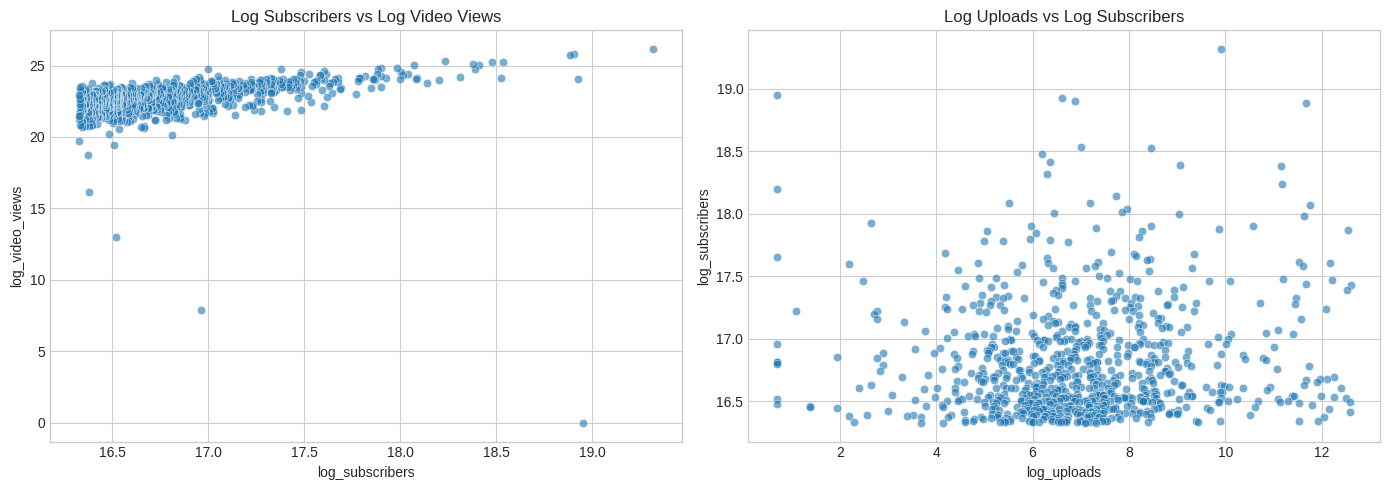

In [ ]:
# Optional log-scale scatterplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df_clean, x="log_subscribers", y="log_video_views", alpha=0.6, ax=axes[0])
axes[0].set_title("Log Subscribers vs Log Video Views")

sns.scatterplot(data=df_clean, x="log_uploads", y="log_subscribers", alpha=0.6, ax=axes[1])
axes[1].set_title("Log Uploads vs Log Subscribers")

plt.tight_layout()
plt.show()


In [ ]:
# ============================================
# 14. TOP VS BOTTOM PERFORMERS
# ============================================
if "performance_category" in df_clean.columns:
    comparison = df_clean.groupby("performance_category")[[
        "subscribers", "video_views", "highest_yearly_earnings"
    ]].agg(["mean", "median", "count"])

    print(comparison)


                       subscribers                     video_views  \
                              mean      median count          mean   
performance_category                                                 
Bottom Performer      1.399282e+07  13700000.0   209  3.456543e+09   
Middle Performer      1.835072e+07  17700000.0   416  8.448460e+09   
Top Performer         4.122967e+07  33500000.0   209  2.519296e+10   

                                         highest_yearly_earnings              \
                            median count                    mean      median   
performance_category                                                           
Bottom Performer      3.303595e+09   209            1.140655e+06    753300.0   
Middle Performer      7.955520e+09   416            4.804593e+06   3500000.0   
Top Performer         1.988315e+10   209            1.813181e+07  11000000.0   

                            
                     count  
performance_category        
Bottom Perf

In [ ]:
# T-test: Top vs Bottom performers
if "performance_category" in df_clean.columns:
    top = df_clean[df_clean["performance_category"] == "Top Performer"]
    bottom = df_clean[df_clean["performance_category"] == "Bottom Performer"]

    for var in ["subscribers", "video_views", "highest_yearly_earnings"]:
        if var in df_clean.columns:
            t_stat, p_val = ttest_ind(
                top[var].dropna(),
                bottom[var].dropna(),
                equal_var=False
            )
            print(f"{var}: t = {t_stat:.3f}, p = {p_val:.5f}")


subscribers: t = 13.762, p = 0.00000
video_views: t = 12.821, p = 0.00000
highest_yearly_earnings: t = 11.875, p = 0.00000


In [ ]:
# ============================================
# 15. CATEGORY-LEVEL SUMMARY
# ============================================
category_summary = df_clean.groupby("category")[[
    "subscribers", "video_views", "uploads", "highest_yearly_earnings"
]].agg(["mean", "median", "count"]).sort_values(("subscribers", "mean"), ascending=False)

category_summary.head(10)


subscribers                     video_views  \
                               mean      median count          mean   
category                                                              
Shows                  4.350833e+07  27600000.0    12  3.649209e+10   
Trailers               3.900000e+07  39000000.0     2  1.663136e+10   
Film & Animation       2.783333e+07  20250000.0    36  1.197870e+10   
Nonprofits & Activism  2.775000e+07  27750000.0     2  5.431456e+09   
Education              2.715476e+07  18450000.0    42  1.619350e+10   
Sports                 2.710909e+07  16400000.0    11  1.345330e+10   
Music                  2.579116e+07  18800000.0   181  1.549508e+10   
Movies                 2.565000e+07  25650000.0     2  7.691628e+09   
People & Blogs         2.175000e+07  17300000.0   104  9.785881e+09   
Entertainment          2.140516e+07  16900000.0   213  1.056883e+10   

                                                 uploads                  \
                             median count           mean    median count   
category                                                                   
Shows                  1.505228e+10    12   29730.666667    3436.0    12   
Trailers               1.663136e+10     2    6839.000000    6839.0     2   
Film & Animation       8.592233e+09    36    3274.114286    1316.0    35   
Nonprofits & Activism  5.431456e+09     2  102912.000000  102912.0     2   
Education              8.379530e+09    42    3446.853659     875.0    41   
Sports                 7.135821e+09    11   14493.727273    1572.0    11   
Music                  1.241387e+10   181    2600.156425     318.0   179   
Movies                 7.691628e+09     2    3553.000000    3553.0     2   
People & Blogs         5.904247e+09   104   11890.752475     772.0   101   
Entertainment          7.828611e+09   213   13701.468900    1385.0   209   

                      highest_yearly_earnings                   
                                         mean     median count  
category                                                        
Shows                            2.641667e+07  9850000.0    12  
Trailers                         4.350000e+06  4350000.0     2  
Film & Animation                 8.638575e+06  3150000.0    36  
Nonprofits & Activism            4.700000e+06  4700000.0     2  
Education                        8.838038e+06  4950000.0    42  
Sports                           9.615118e+06  4100000.0    11  
Music                            7.174226e+06  4300000.0   181  
Movies                           5.450000e+06  5450000.0     2  
People & Blogs                   6.993121e+06  2550000.0   104  
Entertainment                    7.838338e+06  2700000.0   213

/tmp/ipykernel_29248/2866082828.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette="viridis")


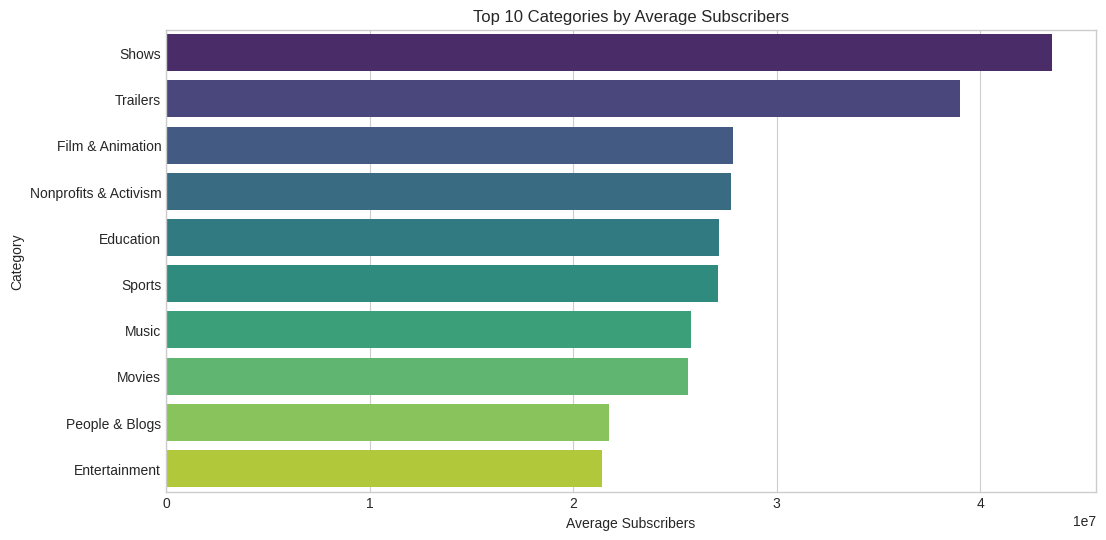

In [ ]:
# ============================================
# 16. TOP CATEGORIES BAR CHART
# ============================================
top_categories = (
    df_clean.groupby("category")["subscribers"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_categories.values, y=top_categories.index, palette="viridis")
plt.title("Top 10 Categories by Average Subscribers")
plt.xlabel("Average Subscribers")
plt.ylabel("Category")
plt.show()


In [ ]:
# ============================================
# 17. ANOVA TEST ACROSS CATEGORIES
# ============================================
# Keep categories with enough observations
cat_counts = df_clean["category"].value_counts()
valid_categories = cat_counts[cat_counts >= 5].index

anova_data = [
    df_clean[df_clean["category"] == cat]["subscribers"].dropna()
    for cat in valid_categories
]

anova_result = f_oneway(*anova_data)
print("ANOVA result for subscribers across categories:")
print(anova_result)


ANOVA result for subscribers across categories:
F_onewayResult(statistic=np.float64(3.1671359793338154), pvalue=np.float64(0.0003231710630479636))


In [ ]:
# ============================================
# 18. COUNTRY SUMMARY
# ============================================
country_summary = df_clean.groupby("country")[[
    "subscribers", "video_views", "highest_yearly_earnings"
]].sum().sort_values("highest_yearly_earnings", ascending=False)

country_summary.head(10)


,subscribers,video_views,highest_yearly_earnings
country,,,
United States,6846400000,3.490818e+12,2.010123e+09
India,4238300000,2.275894e+12,1.772281e+09
Brazil,1221800000,4.812090e+11,3.478070e+08
United Kingdom,905100000,4.283518e+11,1.759068e+08
Pakistan,142400000,1.129919e+11,1.571004e+08
South Korea,446300000,1.989974e+11,1.568286e+08
Argentina,328500000,1.944154e+11,1.506000e+08
Russia,407200000,2.329963e+11,1.387213e+08
Colombia,264500000,1.541978e+11,1.151000e+08


/tmp/ipykernel_29248/1576923195.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="magma")


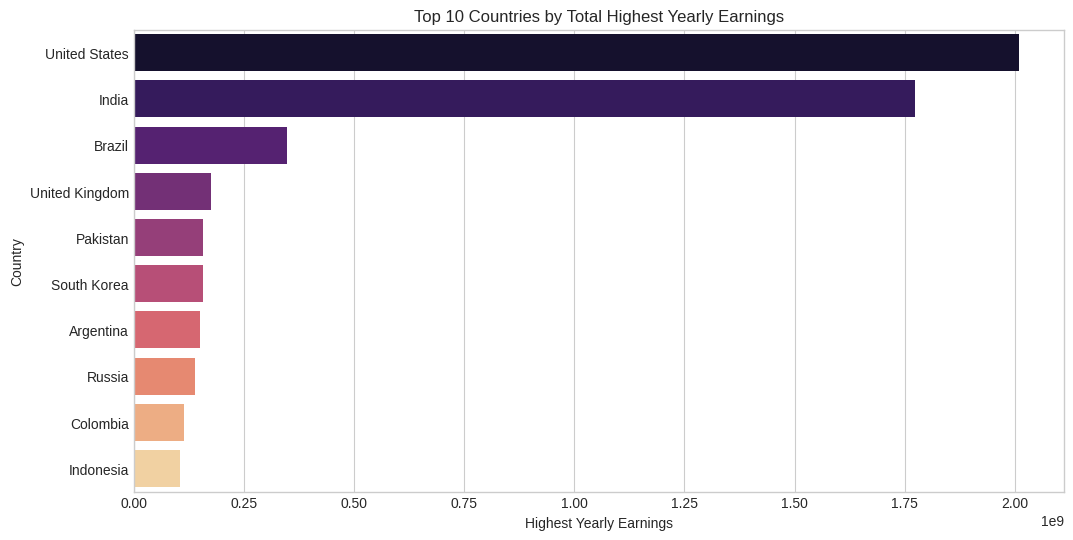

In [ ]:
# ============================================
# 19. TOP COUNTRIES BY ESTIMATED YEARLY EARNINGS
# ============================================
top_countries = country_summary["highest_yearly_earnings"].head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="magma")
plt.title("Top 10 Countries by Total Highest Yearly Earnings")
plt.xlabel("Highest Yearly Earnings")
plt.ylabel("Country")
plt.show()


In [ ]:
# ============================================
# 20. REGRESSION MODEL 1
# Predict subscribers using country-level factors
# ============================================
reg_cols_1 = [
    "subscribers",
    "population",
    "urban_population",
    "gross_tertiary_education_enrollment_(%)",
    "unemployment_rate"
]

reg_df_1 = df_clean[[c for c in reg_cols_1 if c in df_clean.columns]].dropna().copy()

if len(reg_df_1) > 0:
    X = reg_df_1[[
        "population",
        "urban_population",
        "gross_tertiary_education_enrollment_(%)",
        "unemployment_rate"
    ]]
    y = reg_df_1["subscribers"]

    X = sm.add_constant(X)
    model1 = sm.OLS(y, X).fit()
    print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:            subscribers   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     2.441
Date:                Thu, 02 Apr 2026   Prob (F-statistic):             0.0454
Time:                        22:22:38   Log-Likelihood:                -15097.
No. Observations:                 833   AIC:                         3.020e+04
Df Residuals:                     828   BIC:                         3.023e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

In [ ]:
# ============================================
# 21. REGRESSION MODEL 2
# Predict video views using same country-level factors
# ============================================
reg_cols_2 = [
    "video_views",
    "population",
    "urban_population",
    "gross_tertiary_education_enrollment_(%)",
    "unemployment_rate"
]

reg_df_2 = df_clean[[c for c in reg_cols_2 if c in df_clean.columns]].dropna().copy()

if len(reg_df_2) > 0:
    X2 = reg_df_2[[
        "population",
        "urban_population",
        "gross_tertiary_education_enrollment_(%)",
        "unemployment_rate"
    ]]
    y2 = reg_df_2["video_views"]

    X2 = sm.add_constant(X2)
    model2 = sm.OLS(y2, X2).fit()
    print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:            video_views   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.953
Date:                Thu, 02 Apr 2026   Prob (F-statistic):             0.0999
Time:                        22:23:03   Log-Likelihood:                -20698.
No. Observations:                 833   AIC:                         4.141e+04
Df Residuals:                     828   BIC:                         4.143e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

In [ ]:
# ============================================
# 22. SAVE CLEANED DATASET
# ============================================
df_clean.to_csv("cleaned_youtube_statistics.csv", index=False)
print("Cleaned dataset saved successfully.")


Cleaned dataset saved successfully.
